In [2]:
from google.colab import drive
drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
SHOPEE_PATH = FOLDER + 'shopee_reviews.xlsx'
TOKOPEDIA_PATH = FOLDER + 'tokopedia_reviews.xlsx'
OUTPUT_PATH = FOLDER + 'reviews_GABUNGAN.csv'

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
print(os.listdir(FOLDER))

['Dashboard_FullPipeline_Colab.ipynb', 'shopee_reviews.xlsx', 'tokopedia_reviews.xlsx', 'indobert_ckpt', 'reviews_GABUNGAN.csv', 'reviews_CLEAN.csv', 'reviews_CASEFOLD.csv', 'reviews_NORM.csv', 'reviews_TOKEN.csv', 'reviews_STOPWORD.csv', 'reviews_STEMMING.csv', 'hasil_labeling.csv', 'data_test.csv', 'class_weights.npy', 'data_train.csv', 'Penggabungan.ipynb']


In [3]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
SHOPEE_PATH = FOLDER + 'shopee_reviews.xlsx'
TOKOPEDIA_PATH = FOLDER + 'tokopedia_reviews.xlsx'
OUTPUT_PATH = FOLDER + 'reviews_GABUNGAN.csv'
KOLOM = ['platform', 'username', 'rating', 'tanggal', 'content']

# Menampilkan isi folder untuk memastikan nama berkas
print('Isi folder:', os.listdir(FOLDER))


def muat(path, platform):
    """Memuat berkas ulasan, menandai platform asal, dan menyeragamkan kolom."""
    df = pd.read_excel(path)
    df['platform'] = platform
    return df[KOLOM].copy()


shopee = muat(SHOPEE_PATH, 'Shopee')
tokopedia = muat(TOKOPEDIA_PATH, 'Tokopedia')

gabungan = pd.concat([shopee, tokopedia], ignore_index=True)
gabungan['rating'] = pd.to_numeric(gabungan['rating'], errors='coerce')
gabungan.to_csv(OUTPUT_PATH, index=False)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('Ulasan Shopee    :', len(shopee))
print('Ulasan Tokopedia :', len(tokopedia))
print('Total gabungan   :', len(gabungan))
print()
print(gabungan.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Isi folder: ['Dashboard_FullPipeline_Colab.ipynb', 'shopee_reviews.xlsx', 'tokopedia_reviews.xlsx', 'reviews_GABUNGAN.csv', 'reviews_CLEAN.csv', 'reviews_CASEFOLD.csv', 'reviews_NORM.csv', 'reviews_TOKEN.csv', 'reviews_STOPWORD.csv', 'reviews_STEMMING.csv', 'hasil_labeling.csv', 'data_train.csv', 'data_test.csv', 'class_weights.npy', 'indobert_ckpt', 'Penggabungan.ipynb']
Ulasan Shopee    : 3024
Ulasan Tokopedia : 2729
Total gabungan   : 5753

  platform username  rating                   tanggal                                  content
0   Shopee  n*****a     5.0  2024-12-15T14:24:15.000Z  Tekstur:kenyal, kental dan wangi\nAr...
1   Shopee  e*****6     5.0  2024-10-23T06:14:33.000Z  Tekstur:ringan\nAroma:tidak terlalu ...
2   Shopee  n*****n     5.0  2023-07-15T11:26:21.000Z  Tekstur:Lembut\nPerforma:Bagus\n\nIs...
3   Shopee  b*****o     5.0  2024-07-13T05:

**Data Preperation**

In [4]:
!pip install Sastrawi -q

import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi stemmer dan daftar stopword bahasa Indonesia
stemmer = StemmerFactory().create_stemmer()
stopword_list = StopWordRemoverFactory().get_stop_words()

print('Jumlah stopword bahasa Indonesia :', len(stopword_list))
print('Contoh stopword                  :', stopword_list[:8])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00
Jumlah stopword bahasa Indonesia : 126
Contoh stopword                  : ['yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara']


1. Data Cleaning

In [5]:
import os
import re
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
print('Isi folder:', os.listdir(FOLDER))

df = pd.read_csv(FOLDER + 'reviews_GABUNGAN.csv')
print('Data hasil penggabungan     :', len(df))

# Menghapus ulasan yang tidak memiliki isi
df = df.dropna(subset=['content'])
df['content'] = df['content'].astype(str).str.strip()
df = df[df['content'].str.len() > 0]
print('Setelah hapus ulasan kosong :', len(df))

# Menghapus duplikat isi ulasan
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
print('Setelah hapus duplikat      :', len(df))


def cleaning(teks):
    """Menghapus derau karakter pada teks ulasan."""
    teks = re.sub(r'http\S+|www\.\S+', ' ', str(teks))    # tautan
    teks = re.sub(r'_x000D_', ' ', teks)                   # artefak ekspor
    teks = re.sub(r'\b(\w{3,})2\b', r'\1 \1', teks)        # reduplikasi: bener2
    teks = re.sub(r'[^A-Za-z\s]', ' ', teks)               # emoji, angka, tanda baca
    return re.sub(r'\s+', ' ', teks).strip()


df['cleaning'] = df['content'].apply(cleaning)
df = df[df['cleaning'].str.len() > 0].reset_index(drop=True)
print('Data bersih akhir           :', len(df))

df.to_csv(FOLDER + 'reviews_CLEAN.csv', index=False)
# Menampilkan pratinjau hasil cleaning
pd.set_option('display.max_colwidth', 50)

preview = df[['content', 'cleaning']].head(10).copy()
preview.columns = ['ulasan_asli', 'cleaning']
display(preview)
print()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Isi folder: ['Dashboard_FullPipeline_Colab.ipynb', 'shopee_reviews.xlsx', 'tokopedia_reviews.xlsx', 'indobert_ckpt', 'reviews_GABUNGAN.csv', 'reviews_CLEAN.csv', 'reviews_CASEFOLD.csv', 'reviews_NORM.csv', 'reviews_TOKEN.csv', 'reviews_STOPWORD.csv', 'reviews_STEMMING.csv', 'hasil_labeling.csv', 'data_test.csv', 'class_weights.npy', 'data_train.csv', 'Penggabungan.ipynb']
Data hasil penggabungan     : 5753
Setelah hapus ulasan kosong : 5709
Setelah hapus duplikat      : 5400
Data bersih akhir           : 5373


,ulasan_asli,cleaning
0,"Tekstur:kenyal, kental dan wangi\nAroma:ada ar...",Tekstur kenyal kental dan wangi Aroma ada arom...
1,Tekstur:ringan\nAroma:tidak terlalu menyengat ...,Tekstur ringan Aroma tidak terlalu menyengat d...
2,Tekstur:Lembut\nPerforma:Bagus\n\nIsinya penuh...,Tekstur Lembut Performa Bagus Isinya penuh ban...
3,Tekstur:padat dan tahan lama\nAroma:lembut tid...,Tekstur padat dan tahan lama Aroma lembut tida...
4,Tekstur:krim\nPerforma:bagus\nCocok Untuk:ramb...,Tekstur krim Performa bagus Cocok Untuk rambut...
5,Tekstur:halus\nPerforma:bagus\nCocok Untuk:Ram...,Tekstur halus Performa bagus Cocok Untuk Rambu...
6,"packing super aman, pengiriman super cepet, th...",packing super aman pengiriman super cepet than...
7,Barang sesuai dengan pesanan packing rapih pen...,Barang sesuai dengan pesanan packing rapih pen...
8,Pengiriman cepat barang bagus aman packing rap...,Pengiriman cepat barang bagus aman packing rap...
9,Tekstur:cair tapi kental\nAroma:wangi\nEfek:go...,Tekstur cair tapi kental Aroma wangi Efek good...


2. Case Folding

In [6]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'

df = pd.read_csv(FOLDER + 'reviews_CLEAN.csv')
print('Jumlah data:', len(df))

def case_folding(teks):
    """Mengubah seluruh huruf pada teks menjadi huruf kecil."""
    return str(teks).lower()

df['case_folding'] = df['cleaning'].apply(case_folding)
df.to_csv(FOLDER + 'reviews_CASEFOLD.csv', index=False)

# Menampilkan pratinjau hasil case folding
preview = df[['cleaning', 'case_folding']].head(10).copy()
for kolom in preview.columns:
    preview[kolom] = preview[kolom].str.slice(0, 45) + '...'

display(preview.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th',
                            'props': [('text-align', 'center')]}]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah data: 5373


,cleaning,case_folding
0,Tekstur kenyal kental dan wangi Aroma ada aro...,tekstur kenyal kental dan wangi aroma ada aro...
1,Tekstur ringan Aroma tidak terlalu menyengat ...,tekstur ringan aroma tidak terlalu menyengat ...
2,Tekstur Lembut Performa Bagus Isinya penuh ba...,tekstur lembut performa bagus isinya penuh ba...
3,Tekstur padat dan tahan lama Aroma lembut tid...,tekstur padat dan tahan lama aroma lembut tid...
4,Tekstur krim Performa bagus Cocok Untuk rambu...,tekstur krim performa bagus cocok untuk rambu...
5,Tekstur halus Performa bagus Cocok Untuk Ramb...,tekstur halus performa bagus cocok untuk ramb...
6,packing super aman pengiriman super cepet tha...,packing super aman pengiriman super cepet tha...
7,Barang sesuai dengan pesanan packing rapih pe...,barang sesuai dengan pesanan packing rapih pe...
8,Pengiriman cepat barang bagus aman packing ra...,pengiriman cepat barang bagus aman packing ra...
9,Tekstur cair tapi kental Aroma wangi Efek goo...,tekstur cair tapi kental aroma wangi efek goo...


3. Normalization

In [7]:
import re
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'

df = pd.read_csv(FOLDER + 'reviews_CASEFOLD.csv')
print('Jumlah data:', len(df))

KAMUS_SLANG = {
    # kata negasi
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'g': 'tidak',
    'ngga': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak',
    # singkatan umum
    'yg': 'yang', 'bgt': 'banget', 'udh': 'sudah', 'udah': 'sudah',
    'tp': 'tapi', 'tpi': 'tapi', 'jd': 'jadi', 'dgn': 'dengan',
    'krn': 'karena', 'karna': 'karena', 'utk': 'untuk', 'blm': 'belum',
    'dpt': 'dapat', 'klo': 'kalau', 'kalo': 'kalau', 'sy': 'saya',
    'ak': 'aku', 'bs': 'bisa', 'msh': 'masih', 'trs': 'terus',
    'skrg': 'sekarang', 'emg': 'memang', 'emang': 'memang',
    # ejaan tidak baku
    'pake': 'pakai', 'cepet': 'cepat', 'bener': 'benar', 'bnr': 'benar',
    'bgs': 'bagus', 'aja': 'saja', 'aj': 'saja', 'mantul': 'mantap',
    'makasih': 'terima kasih', 'makasi': 'terima kasih', 'mksh': 'terima kasih',
    # serapan bahasa Inggris
    'good': 'bagus', 'nice': 'bagus', 'soft': 'lembut', 'ok': 'oke',
    'thanks': 'terima kasih', 'thankyou': 'terima kasih',
    'recomended': 'direkomendasikan', 'recommended': 'direkomendasikan',
}


def normalization(teks):
    """Menyeragamkan kata tidak baku menjadi bentuk baku."""
    teks = re.sub(r'(.)\1{2,}', r'\1', str(teks))     # rapihhh -> rapih
    return ' '.join(KAMUS_SLANG.get(kata, kata) for kata in teks.split())


df['normalization'] = df['case_folding'].apply(normalization)
df.to_csv(FOLDER + 'reviews_NORM.csv', index=False)

berubah = (df['case_folding'] != df['normalization']).sum()
print('Ulasan yang berubah:', berubah, f'({berubah/len(df)*100:.1f}%)')

# Menampilkan pratinjau hasil normalization
preview = df[['case_folding', 'normalization']].head(10).copy()
for kolom in preview.columns:
    preview[kolom] = preview[kolom].str.slice(0, 45) + '...'

display(preview.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th',
                            'props': [('text-align', 'center')]}]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah data: 5373
Ulasan yang berubah: 3116 (58.0%)


,case_folding,normalization
0,tekstur kenyal kental dan wangi aroma ada aro...,tekstur kenyal kental dan wangi aroma ada aro...
1,tekstur ringan aroma tidak terlalu menyengat ...,tekstur ringan aroma tidak terlalu menyengat ...
2,tekstur lembut performa bagus isinya penuh ba...,tekstur lembut performa bagus isinya penuh ba...
3,tekstur padat dan tahan lama aroma lembut tid...,tekstur padat dan tahan lama aroma lembut tid...
4,tekstur krim performa bagus cocok untuk rambu...,tekstur krim performa bagus cocok untuk rambu...
5,tekstur halus performa bagus cocok untuk ramb...,tekstur halus performa bagus cocok untuk ramb...
6,packing super aman pengiriman super cepet tha...,packing super aman pengiriman super cepat ter...
7,barang sesuai dengan pesanan packing rapih pe...,barang sesuai dengan pesanan packing rapih pe...
8,pengiriman cepat barang bagus aman packing ra...,pengiriman cepat barang bagus aman packing ra...
9,tekstur cair tapi kental aroma wangi efek goo...,tekstur cair tapi kental aroma wangi efek bag...


4. Tokenization

In [8]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'reviews_NORM.csv')


def tokenization(teks):
    return str(teks).split()


df['tokenization'] = df['normalization'].apply(tokenization)
df.to_csv(FOLDER + 'reviews_TOKEN.csv', index=False)

jumlah_token = df['tokenization'].map(len)
print('Total token            :', jumlah_token.sum())
print('Rata-rata token/ulasan :', round(jumlah_token.mean(), 2))

preview = df[['normalization', 'tokenization']].head(10)
display(preview)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total token            : 104325
Rata-rata token/ulasan : 19.42


,normalization,tokenization
0,tekstur kenyal kental dan wangi aroma ada arom...,"[tekstur, kenyal, kental, dan, wangi, aroma, a..."
1,tekstur ringan aroma tidak terlalu menyengat d...,"[tekstur, ringan, aroma, tidak, terlalu, menye..."
2,tekstur lembut performa bagus isinya penuh ban...,"[tekstur, lembut, performa, bagus, isinya, pen..."
3,tekstur padat dan tahan lama aroma lembut tida...,"[tekstur, padat, dan, tahan, lama, aroma, lemb..."
4,tekstur krim performa bagus cocok untuk rambut...,"[tekstur, krim, performa, bagus, cocok, untuk,..."
5,tekstur halus performa bagus cocok untuk rambu...,"[tekstur, halus, performa, bagus, cocok, untuk..."
6,packing super aman pengiriman super cepat teri...,"[packing, super, aman, pengiriman, super, cepa..."
7,barang sesuai dengan pesanan packing rapih pen...,"[barang, sesuai, dengan, pesanan, packing, rap..."
8,pengiriman cepat barang bagus aman packing rap...,"[pengiriman, cepat, barang, bagus, aman, packi..."
9,tekstur cair tapi kental aroma wangi efek bagu...,"[tekstur, cair, tapi, kental, aroma, wangi, ef..."


5. Stopword Removal

In [9]:
!pip install Sastrawi -q

import ast
import pandas as pd
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'reviews_TOKEN.csv')
df['tokenization'] = df['tokenization'].apply(ast.literal_eval)

NEGASI = {'tidak', 'bukan', 'kurang', 'belum', 'jangan'}
stopword_list = [w for w in StopWordRemoverFactory().get_stop_words()
                 if w not in NEGASI]

print('Jumlah stopword setelah pengecualian negasi:', len(stopword_list))


def stopword_removal(tokens):
    return [kata for kata in tokens if kata not in stopword_list]


df['stopword_removal'] = df['tokenization'].apply(stopword_removal)
df.to_csv(FOLDER + 'reviews_STOPWORD.csv', index=False)

display(df[['tokenization', 'stopword_removal']].head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah stopword setelah pengecualian negasi: 124


,tokenization,stopword_removal
0,"[tekstur, kenyal, kental, dan, wangi, aroma, a...","[tekstur, kenyal, kental, wangi, aroma, aroma,..."
1,"[tekstur, ringan, aroma, tidak, terlalu, menye...","[tekstur, ringan, aroma, tidak, terlalu, menye..."
2,"[tekstur, lembut, performa, bagus, isinya, pen...","[tekstur, lembut, performa, bagus, isinya, pen..."
3,"[tekstur, padat, dan, tahan, lama, aroma, lemb...","[tekstur, padat, tahan, lama, aroma, lembut, t..."
4,"[tekstur, krim, performa, bagus, cocok, untuk,...","[tekstur, krim, performa, bagus, cocok, rambut..."
5,"[tekstur, halus, performa, bagus, cocok, untuk...","[tekstur, halus, performa, bagus, cocok, rambu..."
6,"[packing, super, aman, pengiriman, super, cepa...","[packing, super, aman, pengiriman, super, cepa..."
7,"[barang, sesuai, dengan, pesanan, packing, rap...","[barang, sesuai, pesanan, packing, rapih, peng..."
8,"[pengiriman, cepat, barang, bagus, aman, packi...","[pengiriman, cepat, barang, bagus, aman, packi..."
9,"[tekstur, cair, tapi, kental, aroma, wangi, ef...","[tekstur, cair, kental, aroma, wangi, efek, ba..."


6. Stemming

In [10]:
!pip install Sastrawi -q

import ast
import pandas as pd
from google.colab import drive
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'reviews_STOPWORD.csv')
df['stopword_removal'] = df['stopword_removal'].apply(ast.literal_eval)

stemmer = StemmerFactory().create_stemmer()
kamus_stem = {}


def stemming(tokens):
    hasil = []
    for kata in tokens:
        if kata not in kamus_stem:
            kamus_stem[kata] = stemmer.stem(kata)
        hasil.append(kamus_stem[kata])
    return hasil


df['stemming'] = df['stopword_removal'].apply(stemming)
df.to_csv(FOLDER + 'reviews_STEMMING.csv', index=False)

display(df[['stopword_removal', 'stemming']].head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,stopword_removal,stemming
0,"[tekstur, kenyal, kental, wangi, aroma, aroma,...","[tekstur, kenyal, kental, wangi, aroma, aroma,..."
1,"[tekstur, ringan, aroma, tidak, terlalu, menye...","[tekstur, ringan, aroma, tidak, terlalu, senga..."
2,"[tekstur, lembut, performa, bagus, isinya, pen...","[tekstur, lembut, performa, bagus, isi, penuh,..."
3,"[tekstur, padat, tahan, lama, aroma, lembut, t...","[tekstur, padat, tahan, lama, aroma, lembut, t..."
4,"[tekstur, krim, performa, bagus, cocok, rambut...","[tekstur, krim, performa, bagus, cocok, rambut..."
5,"[tekstur, halus, performa, bagus, cocok, rambu...","[tekstur, halus, performa, bagus, cocok, rambu..."
6,"[packing, super, aman, pengiriman, super, cepa...","[packing, super, aman, kirim, super, cepat, te..."
7,"[barang, sesuai, pesanan, packing, rapih, peng...","[barang, sesuai, pesan, packing, rapih, kirim,..."
8,"[pengiriman, cepat, barang, bagus, aman, packi...","[kirim, cepat, barang, bagus, aman, packing, r..."
9,"[tekstur, cair, kental, aroma, wangi, efek, ba...","[tekstur, cair, kental, aroma, wangi, efek, ba..."


**Data Labelling**

In [11]:
!pip install Sastrawi
!pip install -q Sastrawi wordcloud gensim
import ast
import pandas as pd
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'reviews_STEMMING.csv')

def pelabelan(rating):
    if rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    return 'Negatif'


df['label'] = df['rating'].apply(pelabelan)
display(df[['content', 'rating', 'label']].head(10))

print(df['label'].value_counts())

df.to_csv(FOLDER + 'hasil_labeling.csv', index=False)

print("File berhasil disimpan sebagai 'hasil_labeling.csv'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.7 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,content,rating,label
0,"Tekstur:kenyal, kental dan wangi\nAroma:ada ar...",5.0,Positif
1,Tekstur:ringan\nAroma:tidak terlalu menyengat ...,5.0,Positif
2,Tekstur:Lembut\nPerforma:Bagus\n\nIsinya penuh...,5.0,Positif
3,Tekstur:padat dan tahan lama\nAroma:lembut tid...,5.0,Positif
4,Tekstur:krim\nPerforma:bagus\nCocok Untuk:ramb...,5.0,Positif
5,Tekstur:halus\nPerforma:bagus\nCocok Untuk:Ram...,5.0,Positif
6,"packing super aman, pengiriman super cepet, th...",5.0,Positif
7,Barang sesuai dengan pesanan packing rapih pen...,4.0,Positif
8,Pengiriman cepat barang bagus aman packing rap...,5.0,Positif
9,Tekstur:cair tapi kental\nAroma:wangi\nEfek:go...,5.0,Positif


label
Positif    5074
Netral      155
Negatif     144
Name: count, dtype: int64
File berhasil disimpan sebagai 'hasil_labeling.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== DISTRIBUSI HASIL PELABELAN ===
         Jumlah  Persentase (%)
label                          
Positif  5074.0           94.44
Netral    155.0            2.88
Negatif   144.0            2.68
Total    5373.0          100.00

=== CONTOH HASIL PELABELAN ===


,Rating,Label,Content
0,5.0,Positif,"Tekstur:kenyal, kental dan wangi\nAroma:ada ar..."
1,5.0,Positif,Tekstur:ringan\nAroma:tidak terlalu menyengat ...
2,3.0,Netral,"Wanginya enak, tekstur nya lembut berminyak gi..."
3,3.0,Netral,Tekstur:lembut\nAroma:standar\nEfek:belum ada ...
4,2.0,Negatif,Tekstur:sedikit berminyak\nAroma:wangi\nEfek:b...
5,2.0,Negatif,Tekstur:terlalu oily!\nAroma:Wangi\nEfek:diram...


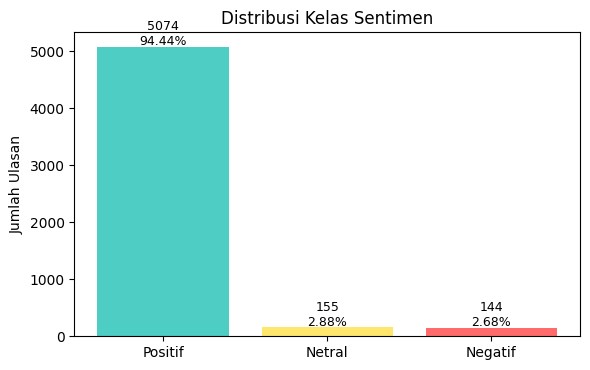

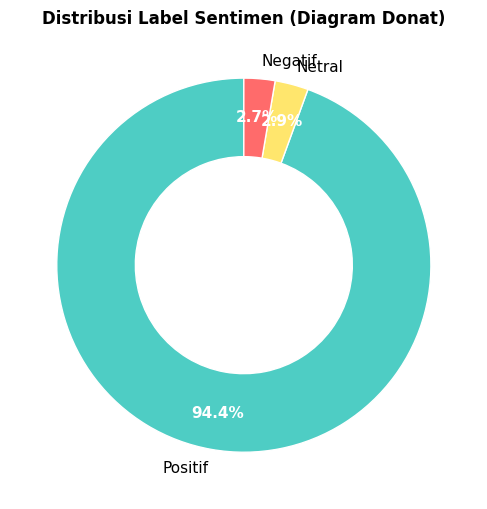

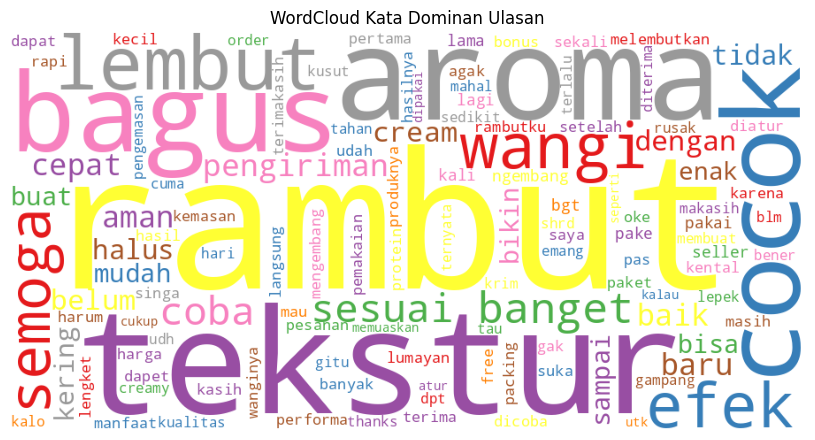

In [12]:
# ===== SEL: MENAMPILKAN & VISUALISASI HASIL PELABELAN =====
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import drive # Added this import
drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'hasil_labeling.csv')

# --- 1. Muat data berlabel ---
# The dataframe 'df' is already loaded correctly from FOLDER + 'hasil_labeling.csv' above.
# Removed redundant lines that caused FileNotFoundError and duplicate loading.
if 'label' not in df.columns:
    df['label'] = df['rating'].apply(
        lambda r: 'Positif' if r >= 4 else ('Netral' if r == 3 else 'Negatif'))

ORDER = ['Positif', 'Netral', 'Negatif']
COL   = {'Positif': '#4ECDC4', 'Netral': '#FFE66D', 'Negatif': '#FF6B6B'} # Reverted to original colors as per user's latest context

# --- 2. Tabel distribusi (jumlah + persentase) ---
dist  = df['label'].value_counts().reindex(ORDER)
tabel = pd.DataFrame({'Jumlah': dist, 'Persentase (%)': (dist/len(df)*100).round(2)})
tabel.loc['Total'] = [len(df), 100.0]
print("=== DISTRIBUSI HASIL PELABELAN ===")
print(tabel.to_string())

# --- 3. Contoh hasil pelabelan per kelas ---
print("\n=== CONTOH HASIL PELABELAN ===")
example_reviews = []
for s in ORDER:
    for _, row in df[df['label'] == s].head(2).iterrows():
        example_reviews.append({
            'Rating': f"{row['rating']}",
            'Label': s,
            'Content': str(row['content']).strip()[:65]
        })

display(pd.DataFrame(example_reviews)) # Reinstated table display


# --- 4. Grafik 1: Bar chart distribusi ---
plt.figure(figsize=(6, 3.8))
bars = plt.bar(ORDER, [dist[s] for s in ORDER], color=[COL[s] for s in ORDER])
for b, s in zip(bars, ORDER):
    plt.text(b.get_x()+b.get_width()/2, dist[s]+30,
             f"{dist[s]}\n{dist[s]/len(df)*100:.2f}%", ha='center', fontsize=9)
plt.ylabel('Jumlah Ulasan'); plt.title('Distribusi Kelas Sentimen')
plt.tight_layout(); plt.savefig('fig_distribusi_sentimen.png', dpi=130); plt.show()

# --- 5. Grafik 2: Doughnut chart ---
plt.figure(figsize=(5.2, 5.2))
w, _, at = plt.pie(dist.values, labels=ORDER, colors=[COL[s] for s in ORDER],
    autopct=lambda p: f'{p:.1f}%', startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.42, edgecolor='white'), textprops={'fontsize': 11})
for a in at: a.set_fontweight('bold'); a.set_color('white')
plt.title('Distribusi Label Sentimen (Diagram Donat)', fontweight='bold')
plt.tight_layout(); plt.savefig('fig_donut_sentimen.png', dpi=130); plt.show()

# --- 6. Grafik 3: WordCloud seluruh ulasan ---
STOP = {'yang','dan','untuk','juga','tapi','tetapi','sudah','begitu','hanya','saja','sama',
        'aku','jadi','lebih','sangat','memang','ini','itu','ada','di','ke','dari','nya',
        'ya','aja','sih','kok','deh','produk','barang','beli'}
def bersih(t):
    t = re.sub(r'[^a-z\s]', ' ', str(t).lower())
    return [w for w in t.split() if w not in STOP and len(w) > 2]
freq = {}
for t in df['content']:
    for w in bersih(t): freq[w] = freq.get(w, 0) + 1
wc = WordCloud(width=900, height=450, background_color='white', colormap='Set1',
               max_words=120, prefer_horizontal=0.9).generate_from_frequencies(freq)
plt.figure(figsize=(9, 4.5)); plt.imshow(wc); plt.axis('off')
plt.title('WordCloud Kata Dominan Ulasan')
plt.tight_layout(); plt.savefig('fig_wordcloud_all.png', dpi=130); plt.show()

**Data Splitiing**

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'hasil_labeling.csv')

# --- encode label -> id (Negatif=0, Netral=1, Positif=2) ---
label2id = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
id2label = {v: k for k, v in label2id.items()}
df['label_id'] = df['label'].map(label2id)

# --- stratified split 80:20 ---
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['label_id'], random_state=42)

# --- class weights (dari data latih) ---
class_weights = compute_class_weight(
    'balanced', classes=np.array([0, 1, 2]), y=train_df['label_id'].values)

# ================= TAMPILKAN HASIL DALAM TABEL =================
ORDER = ['Positif', 'Netral', 'Negatif']

# Tabel 4.4 — distribusi hasil pembagian data
tabel_split = pd.DataFrame({
    'Data Latih (80%)': train_df['label'].value_counts().reindex(ORDER),
    'Data Uji (20%)':   test_df['label'].value_counts().reindex(ORDER),
})
tabel_split['Total'] = tabel_split.sum(axis=1)
tabel_split.loc['Total'] = tabel_split.sum()          # baris total
tabel_split.index.name = 'Kelas'
print("Tabel 4.4 Hasil Pembagian Data Latih dan Data Uji")
display(tabel_split)

# Tabel 4.5 — bobot kelas (class weight)
tabel_bobot = pd.DataFrame({
    'Kelas': [id2label[i] for i in [0, 1, 2]],
    'Bobot (Class Weight)': [round(class_weights[i], 3) for i in [0, 1, 2]],
})
print("\nTabel 4.5 Bobot Kelas (Class Weight)")
display(tabel_bobot)

# --- simpan ---
train_df.to_csv(FOLDER + 'data_train.csv', index=False)
test_df.to_csv(FOLDER + 'data_test.csv', index=False)
np.save(FOLDER + 'class_weights.npy', class_weights)
print("\nFile berhasil disimpan: 'data_train.csv', 'data_test.csv', 'class_weights.npy'")

Tabel 4.4 Hasil Pembagian Data Latih dan Data Uji


,Data Latih (80%),Data Uji (20%),Total
Kelas,,,
Positif,4059,1015,5074
Netral,124,31,155
Negatif,115,29,144
Total,4298,1075,5373



Tabel 4.5 Bobot Kelas (Class Weight)


,Kelas,Bobot (Class Weight)
0,Negatif,12.458
1,Netral,11.554
2,Positif,0.353



File berhasil disimpan: 'data_train.csv', 'data_test.csv', 'class_weights.npy'


**Modeling**

In [15]:
import torch
print("CUDA tersedia:", torch.cuda.is_available())
print("Nama GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Tidak ada GPU")

CUDA tersedia: False
Nama GPU: Tidak ada GPU


In [16]:
print(label2id)
print(id2label)

{'Negatif': 0, 'Netral': 1, 'Positif': 2}
{0: 'Negatif', 1: 'Netral', 2: 'Positif'}


IndoBERTAnalisis Sentimen (IndoBERT)

In [ ]:
import numpy as np, pandas as pd, torch
from torch import nn
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, AutoConfig)
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
MODEL  = 'indobenchmark/indobert-base-p1'
label2id = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
id2label = {v: k for k, v in label2id.items()}

train_df = pd.read_csv(FOLDER + 'data_train.csv')
test_df   = pd.read_csv(FOLDER + 'data_test.csv')
class_weights = np.load(FOLDER + 'class_weights.npy')

# teks untuk IndoBERT = hasil normalisasi (konteks terjaga, TANPA stemming)
TEXT = 'ulasan_normalisasi' if 'ulasan_normalisasi' in train_df.columns else 'content'
for d in (train_df, test_df):
    d[TEXT]    = d[TEXT].astype(str)
    d['labels'] = d['label'].map(label2id)

tokenizer = AutoTokenizer.from_pretrained(MODEL)
def tok(b): return tokenizer(b[TEXT], truncation=True, max_length=128)
ds_train = Dataset.from_pandas(train_df[[TEXT, 'labels']].reset_index(drop=True)).map(tok, batched=True)
ds_test  = Dataset.from_pandas(test_df[[TEXT, 'labels']].reset_index(drop=True)).map(tok, batched=True)

# The previous attempt to load and modify the config was not fully effective.
# Pass num_labels, id2label, and label2id directly to from_pretrained.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=len(label2id), # Explicitly set the number of labels for the classification head
    id2label=id2label,         # Provide the custom id2label mapping
    label2id=label2id          # Provide the custom label2id mapping
)

cw = torch.tensor(class_weights, dtype=torch.float)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=cw.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {'accuracy': accuracy_score(p.label_ids, preds),
            'macro_f1': f1_score(p.label_ids, preds, average='macro')}

args = TrainingArguments(
    output_dir=FOLDER + 'indobert_ckpt',
    num_train_epochs=6, per_device_train_batch_size=16, per_device_eval_batch_size=32,
    fp16=True,
    learning_rate=2e-5, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='macro_f1',
    logging_steps=50, seed=42, report_to='none')

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    # class_weights=class_weights, # Removed as it's not a valid argument for Trainer.__init__
)

trainer.train()

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4298 [00:00<?, ? examples/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.832401,1.393340,0.946047,0.500777


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# ===== 4.5.1 — EVALUASI IndoBERT (untuk Tabel 4.6 + Gambar 4.10) =====
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
labels_urut = ['Negatif', 'Netral', 'Positif']     # sesuai id 0,1,2

# --- prediksi pada data uji ---
pred_out = trainer.predict(ds_test)
y_true = pred_out.label_ids
y_pred = pred_out.predictions.argmax(-1)

# --- 1. Angka utama (untuk kalimat di narasi) ---
acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')
print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro-F1 : {mf1:.4f}")

# --- 2. Classification report (isi Tabel 4.6) ---
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=labels_urut, digits=4))

# --- 3. Confusion Matrix (Gambar 4.10) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_urut, yticklabels=labels_urut, cbar=False)
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.title('Confusion Matrix — IndoBERT')
plt.tight_layout()
plt.savefig(FOLDER + 'fig_confusion_matrix.png', dpi=150)   # <-- file untuk disisipkan
plt.show()
print("\nGambar disimpan:", FOLDER + 'fig_confusion_matrix.png')

In [ ]:
import matplotlib.pyplot as plt

FOLDER = '/content/drive/MyDrive/SKRIPSI/'

logs = trainer.state.log_history

epochs_train, train_loss = [], []
epochs_eval, val_loss, val_acc, val_f1 = [], [], [], []

for log in logs:
    if 'loss' in log and 'epoch' in log and 'eval_loss' not in log:
        epochs_train.append(log['epoch'])
        train_loss.append(log['loss'])
    if 'eval_loss' in log:
        epochs_eval.append(log['epoch'])
        val_loss.append(log['eval_loss'])
        val_acc.append(log.get('eval_accuracy'))
        val_f1.append(log.get('eval_macro_f1'))

In [ ]:
# Tambahkan tepat SEBELUM baris from_pretrained
print("label2id:", label2id)
print("id2label:", id2label)

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

In [ ]:
print(model.config.num_labels)   # harus keluar: 3
print(model.config.id2label)     # harus keluar: {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
print(model.classifier)          # cek shape output layer terakhir, harus out_features=3

In [ ]:
# ===== Klasifikasi seluruh ulasan dengan model terlatih =====
df_all = pd.read_csv(FOLDER + 'hasil_labeling.csv')
df_all[TEXT] = df_all[TEXT].astype(str)
ds_all = Dataset.from_pandas(df_all[[TEXT]].reset_index(drop=True)).map(tok, batched=True)

pred = trainer.predict(ds_all).predictions.argmax(-1)
df_all['sentimen_pred'] = [id2label[i] for i in pred]
df_all.to_csv(FOLDER + 'hasil_prediksi.csv', index=False)
print(df_all['sentimen_pred'].value_counts())
print("Disimpan: hasil_prediksi.csv")

Topic Modeling (LDA)

In [ ]:
# MODELING — LDA pada kelas Negatif
!pip install -q gensim wordcloud
import ast, pandas as pd, matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'hasil_prediksi.csv')

# ambil ulasan kelas Negatif; token dari kolom stemming (hasil preprocessing)
neg = df[df['sentimen_pred'] == 'Negatif'].copy()
docs = [ast.literal_eval(x) if isinstance(x, str) else x for x in neg['stemming']]
docs = [d for d in docs if d]

dictionary = corpora.Dictionary(docs)
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(d) for d in docs]
corpus = [c for c in corpus if c]
print("Kata unik:", len(dictionary), "| Dokumen:", len(corpus))

# --- sweep k, pilih coherence c_v tertinggi ---
hasil = {}
for k in range(2, 9):
    m = LdaModel(corpus, id2word=dictionary, num_topics=k, random_state=42,
                 passes=20, iterations=300, alpha='auto', eta='auto')
    cv = CoherenceModel(model=m, texts=docs, dictionary=dictionary, coherence='c_v').get_coherence()
    hasil[k] = (cv, m); print(f"k={k}: c_v={cv:.4f}")

best_k = max(hasil, key=lambda k: hasil[k][0])
best_cv, lda = hasil[best_k]
print(f">> k optimal = {best_k} (c_v={best_cv:.4f})")

# grafik coherence
plt.figure(figsize=(5.5, 3.4))
plt.plot(list(hasil), [hasil[k][0] for k in hasil], 'o-', color='#c62828')
plt.scatter([best_k], [best_cv], color='k', s=80, zorder=5)
plt.xlabel('Jumlah topik (k)'); plt.ylabel('Coherence c_v'); plt.title('Pemilihan k Optimal LDA')
plt.tight_layout(); plt.savefig(FOLDER + 'fig_lda_coherence.png', dpi=130); plt.show()

# topik + wordcloud
for t in range(best_k):
    print(f"Topik {t+1}:", ', '.join(w for w, _ in lda.show_topic(t, topn=10)))
fig, ax = plt.subplots(1, best_k, figsize=(3.1 * best_k, 3.1))
ax = [ax] if best_k == 1 else ax
for t in range(best_k):
    wc = WordCloud(width=400, height=400, background_color='white', colormap='Set1'
        ).generate_from_frequencies({w: p for w, p in lda.show_topic(t, topn=20)})
    ax[t].imshow(wc); ax[t].axis('off'); ax[t].set_title(f'Topik {t+1}')
plt.tight_layout(); plt.savefig(FOLDER + 'fig_lda_topik.png', dpi=130); plt.show()

In [ ]:
# MODELING — LDA pada kelas Netral dan Negatif
!pip install -q gensim wordcloud
import ast, pandas as pd, matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'hasil_prediksi.csv')


def run_lda_untuk_kelas(df, kelas, folder, k_range=range(2, 9), warna='#c62828'):
    """
    Menjalankan LDA topic modeling untuk satu kelas sentimen tertentu
    (mis. 'Negatif' atau 'Netral'), lalu menyimpan grafik coherence
    dan wordcloud topik ke folder yang ditentukan.
    """
    print(f"\n{'='*60}")
    print(f"MODELING LDA — Kelas: {kelas}")
    print(f"{'='*60}")

    # ambil ulasan sesuai kelas; token dari kolom stemming (hasil preprocessing)
    subset = df[df['sentimen_pred'] == kelas].copy()
    docs = [ast.literal_eval(x) if isinstance(x, str) else x for x in subset['stemming']]
    docs = [d for d in docs if d]

    if len(docs) < 5:
        print(f"Data terlalu sedikit untuk kelas {kelas} ({len(docs)} dokumen). Dilewati.")
        return None

    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(d) for d in docs]
    corpus = [c for c in corpus if c]
    print("Kata unik:", len(dictionary), "| Dokumen:", len(corpus))

    # --- sweep k, pilih coherence c_v tertinggi ---
    hasil = {}
    for k in k_range:
        m = LdaModel(corpus, id2word=dictionary, num_topics=k, random_state=42,
                     passes=20, iterations=300, alpha='auto', eta='auto')
        cv = CoherenceModel(model=m, texts=docs, dictionary=dictionary,
                             coherence='c_v').get_coherence()
        hasil[k] = (cv, m)
        print(f"k={k}: c_v={cv:.4f}")

    best_k = max(hasil, key=lambda k: hasil[k][0])
    best_cv, lda = hasil[best_k]
    print(f">> k optimal untuk {kelas} = {best_k} (c_v={best_cv:.4f})")

    # grafik coherence
    plt.figure(figsize=(5.5, 3.4))
    plt.plot(list(hasil), [hasil[k][0] for k in hasil], 'o-', color=warna)
    plt.scatter([best_k], [best_cv], color='k', s=80, zorder=5)
    plt.xlabel('Jumlah topik (k)')
    plt.ylabel('Coherence c_v')
    plt.title(f'Pemilihan k Optimal LDA — Kelas {kelas}')
    plt.tight_layout()
    plt.savefig(folder + f'fig_lda_coherence_{kelas.lower()}.png', dpi=130)
    plt.show()

    # topik + wordcloud
    for t in range(best_k):
        print(f"Topik {t+1}:", ', '.join(w for w, _ in lda.show_topic(t, topn=10)))

    fig, ax = plt.subplots(1, best_k, figsize=(3.1 * best_k, 3.1))
    ax = [ax] if best_k == 1 else ax
    for t in range(best_k):
        wc = WordCloud(width=400, height=400, background_color='white', colormap='Set1'
            ).generate_from_frequencies({w: p for w, p in lda.show_topic(t, topn=20)})
        ax[t].imshow(wc)
        ax[t].axis('off')
        ax[t].set_title(f'Topik {t+1}')
    plt.tight_layout()
    plt.savefig(folder + f'fig_lda_topik_{kelas.lower()}.png', dpi=130)
    plt.show()

    return {'best_k': best_k, 'best_cv': best_cv, 'model': lda, 'dictionary': dictionary}


# ================= EKSEKUSI UNTUK KELAS NEGATIF DAN NETRAL =================
warna_kelas = {
    'Negatif': '#c62828',   # merah
    'Netral':  '#f9a825',   # kuning/oranye
}

hasil_semua = {}
for kelas in ['Negatif', 'Netral']:
    hasil_semua[kelas] = run_lda_untuk_kelas(
        df, kelas, FOLDER, k_range=range(2, 9), warna=warna_kelas[kelas]
    )

print("\nSelesai. Ringkasan k optimal per kelas:")
for kelas, hasil in hasil_semua.items():
    if hasil:
        print(f"- {kelas}: k={hasil['best_k']}, coherence={hasil['best_cv']:.4f}")

In [ ]:
# ===== GRAFIK COHERENCE per KELAS (Gambar 4.12) =====
import matplotlib.pyplot as plt
FOLDER = '/content/drive/MyDrive/SKRIPSI/'

# nilai c_v hasil sweep (k=2..8) — dari output kamu
coherence = {
    'Negatif': [0.3298, 0.2887, 0.3399, 0.2798, 0.3042, 0.3435, 0.3838],
    'Netral':  [0.4680, 0.3749, 0.3545, 0.4281, 0.4299, 0.3625, 0.3922],
    'Positif': [0.5069, 0.5699, 0.5844, 0.5684, 0.5264, 0.5087, 0.5353],
}
ks      = list(range(2, 9))
warna   = {'Negatif': '#c62828', 'Netral': '#f9a825', 'Positif': '#2e7d32'}
marker  = {'Negatif': 'o', 'Netral': 's', 'Positif': '^'}
optimal = {'Negatif': 8, 'Netral': 2, 'Positif': 4}     # k dgn c_v tertinggi

plt.figure(figsize=(7, 4.2))
for kelas, cv in coherence.items():
    plt.plot(ks, cv, marker[kelas] + '-', color=warna[kelas], label=kelas, linewidth=2)
    ko = optimal[kelas]
    plt.scatter([ko], [cv[ks.index(ko)]], color=warna[kelas], s=150, edgecolor='k', zorder=5)
plt.xlabel('Jumlah topik (k)'); plt.ylabel('Coherence c_v')
plt.title('Perbandingan Nilai Coherence c_v per Kelas Sentimen')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FOLDER + 'fig_lda_coherence.png', dpi=150)
plt.show()

In [ ]:
# ===== WORDCLOUD TOPIK LDA per KELAS (Gambar 4.13) =====
import ast, pandas as pd, matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud

FOLDER = '/content/drive/MyDrive/SKRIPSI/'
df = pd.read_csv(FOLDER + 'hasil_prediksi.csv')

K_OPTIMAL = {'Negatif': 8, 'Netral': 2, 'Positif': 4}   # dari hasil sweep
KELAS     = 'Negatif'                                    # <-- ganti: 'Netral' / 'Positif'

# ambil dokumen kelas terpilih (token dari kolom stemming)
sub  = df[df['sentimen_pred'] == KELAS]
docs = [ast.literal_eval(x) if isinstance(x, str) else x for x in sub['stemming']]
docs = [d for d in docs if d]

dic = corpora.Dictionary(docs); dic.filter_extremes(no_below=2, no_above=0.5)
corpus = [dic.doc2bow(d) for d in docs]
lda = LdaModel(corpus, id2word=dic, num_topics=K_OPTIMAL[KELAS],
               random_state=42, passes=20, iterations=300, alpha='auto', eta='auto')

k = K_OPTIMAL[KELAS]
cols = min(k, 4); rows = (k + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows))
axes = axes.flatten() if k > 1 else [axes]
cmap = 'Reds' if KELAS == 'Negatif' else ('Oranges' if KELAS == 'Netral' else 'Greens')
for t in range(k):
    freq = {w: p for w, p in lda.show_topic(t, topn=20)}
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap=cmap, prefer_horizontal=0.9).generate_from_frequencies(freq)
    axes[t].imshow(wc); axes[t].axis('off'); axes[t].set_title(f'Topik {t+1}', fontsize=12)
for j in range(k, len(axes)):
    axes[j].axis('off')
plt.suptitle(f'WordCloud Topik Keluhan — Kelas {KELAS}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FOLDER + f'fig_wordcloud_{KELAS.lower()}.png', dpi=150)
plt.show()